## KNeighborsRegresso
KNeighborsRegressor predicts a numerical value by finding the K most similar training samples.
```
New person
   ↓
Find 3 nearest people
   ↓
Salaries: 50,000, 55,000, 60,000
   ↓
Prediction = average = 55,000
```

$$prediction=\frac{Neighbor_1+Neighbor_2+....+Neighbor_k}{k}$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
data = {
    "age": [
        22, 25, 28, 30, 35, 40, 45, 32, 27, 50,
        24, 29, 33, 38, 42, 48, 26, 31, 36, 44,
        23, 34, 37, 41, 46, 28, 39, 43, 30, 47
    ],

    "experience": [
        1, 2, 4, 5, 10, 15, 20, 7, 3, 25,
        1, 5, 8, 12, 17, 22, 2, 6, 11, 18,
        1, 9, 13, 16, 21, 4, 14, 17, 6, 23
    ],

    # 1 = Bachelor, 2 = Master, 3 = PhD
    "education_level": [
        1, 1, 2, 2, 2, 3, 3, 2, 1, 3,
        1, 2, 2, 3, 3, 3, 1, 2, 2, 3,
        1, 2, 3, 3, 3, 2, 2, 3, 2, 3
    ],

    "projects": [
        2, 3, 6, 8, 15, 20, 30, 10, 4, 35,
        2, 7, 12, 18, 25, 32, 3, 9, 16, 28,
        2, 14, 19, 23, 31, 6, 21, 26, 10, 34
    ],

    "salary": [
        25000, 30000, 42000, 50000, 75000,
        100000, 135000, 62000, 35000, 160000,
        27000, 48000, 68000, 90000, 115000,
        145000, 32000, 57000, 80000, 125000,
        26000, 72000, 95000, 108000, 140000,
        43000, 97000, 120000, 58000, 150000
    ]
}

df = pd.DataFrame(data)

df.head()

,age,experience,education_level,projects,salary
0,22,1,1,2,25000
1,25,2,1,3,30000
2,28,4,2,6,42000
3,30,5,2,8,50000
4,35,10,2,15,75000


In [3]:
X = df.drop(columns=["salary"])
y = df["salary"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,age,experience,education_level,projects
0,22,1,1,2
1,25,2,1,3
2,28,4,2,6
3,30,5,2,8
4,35,10,2,15



Target:


0    25000
1    30000
2    42000
3    50000
4    75000
Name: salary, dtype: int64

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 22
Testing samples: 8


In [5]:
model = Pipeline([
    ("scaler", StandardScaler()),

    ("knn", KNeighborsRegressor(
        n_neighbors=5,
        weights="distance",
        metric="minkowski",
        p=2
    ))
])

In [6]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [7]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

results

,Actual Salary,Predicted Salary
0,120000,117291.666119
1,145000,136026.970438
2,108000,106993.178080
3,57000,54572.001394
4,35000,29229.669979
5,160000,134619.966916
6,58000,53912.717472
7,140000,132566.232354


In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 7223.45
MSE  : 105521095.91
RMSE : 10272.35
R²   : 0.9454


In [9]:
new_person = pd.DataFrame({
    "age": [34],
    "experience": [9],
    "education_level": [2],
    "projects": [14]
})

predicted_salary = model.predict(new_person)

print(f"Predicted salary: {predicted_salary[0]:,.2f}")

Predicted salary: 72,000.00


In [10]:
scaler = model.named_steps["scaler"]
knn = model.named_steps["knn"]

new_person_scaled = scaler.transform(new_person)

distances, indexes = knn.kneighbors(new_person_scaled)

print("Neighbor indexes:", indexes[0])
print("Neighbor distances:", distances[0])

Neighbor indexes: [12  2  0 14 17]
Neighbor distances: [0.         0.23123596 0.29381279 0.46247193 0.58762557]


In [11]:
neighbor_rows = X_train.iloc[indexes[0]].copy()

neighbor_rows["salary"] = y_train.iloc[indexes[0]].values
neighbor_rows["distance"] = distances[0]

neighbor_rows

,age,experience,education_level,projects,salary,distance
21,34,9,2,14,72000,0.000000
4,35,10,2,15,75000,0.231236
12,33,8,2,12,68000,0.293813
18,36,11,2,16,80000,0.462472
7,32,7,2,10,62000,0.587626


In [12]:
neighbor_salaries = y_train.iloc[indexes[0]].values

manual_average = np.mean(neighbor_salaries)

print("Neighbor salaries:", neighbor_salaries)
print("Simple average:", manual_average)

Neighbor salaries: [72000 75000 68000 80000 62000]
Simple average: 71400.0


In [13]:
neighbor_salaries = y_train.iloc[indexes[0]].values
neighbor_distances = distances[0]

weights = 1 / neighbor_distances

weighted_prediction = np.sum(
    weights * neighbor_salaries
) / np.sum(weights)

print(f"Manual weighted prediction: {weighted_prediction:,.2f}")
print(f"Model prediction: {model.predict(new_person)[0]:,.2f}")

Manual weighted prediction: nan
Model prediction: 72,000.00


/tmp/ipykernel_28823/4088355715.py:4: RuntimeWarning: divide by zero encountered in divide
  weights = 1 / neighbor_distances
/tmp/ipykernel_28823/4088355715.py:6: RuntimeWarning: invalid value encountered in scalar divide
  weighted_prediction = np.sum(


In [14]:
k_values = range(1, 16)
mae_scores = []

for k in k_values:

    test_model = Pipeline([
        ("scaler", StandardScaler()),

        ("knn", KNeighborsRegressor(
            n_neighbors=k,
            weights="distance"
        ))
    ])

    test_model.fit(X_train, y_train)

    prediction = test_model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)

    mae_scores.append(mae)

for k, score in zip(k_values, mae_scores):
    print(f"K = {k:2d}, MAE = {score:.2f}")

K =  1, MAE = 6250.00
K =  2, MAE = 2999.85
K =  3, MAE = 5204.75
K =  4, MAE = 5563.24
K =  5, MAE = 7223.45
K =  6, MAE = 8477.31
K =  7, MAE = 8479.53
K =  8, MAE = 9147.30
K =  9, MAE = 9437.80
K = 10, MAE = 10124.53
K = 11, MAE = 11059.93
K = 12, MAE = 12102.84
K = 13, MAE = 13233.42
K = 14, MAE = 14201.44
K = 15, MAE = 15123.33


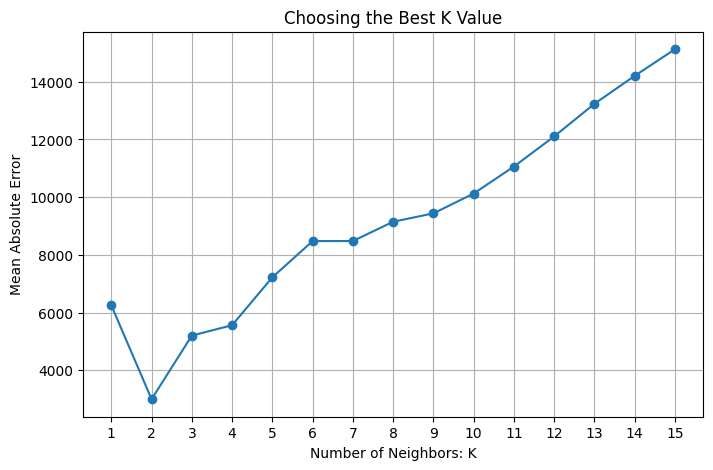

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    mae_scores,
    marker="o"
)

plt.xlabel("Number of Neighbors: K")
plt.ylabel("Mean Absolute Error")
plt.title("Choosing the Best K Value")
plt.xticks(list(k_values))
plt.grid()
plt.show()